In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
%matplotlib inline

In [2]:
import warnings 
from scipy.stats import mode
#avoid the warning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)

# Data read

In [3]:
data_df = pd.read_csv("dog_adaptability.csv")
data_df.head()

,id,adaptability,good_for_novice_owners,sensitivity_level,tolerates_being_alone,tolerates_cold_weather,tolerates_hot_weather,all_around_friendliness,affectionate_with_family,incredibly_kifriendly_dogs,...,wanderlust_potential,exercise_needs,energy_level,intensity,potential_for_playfulness,breed_group,height,weight,lifspan,adapts_well_to_apartment_living
0,0,3,2,5.0,1,4,3,5,5,4,...,5,4.0,4,4.0,5,Mixed Breed Dogs,7 to 11 inches,70 to 115 pounds,10 to 15 years,Flexible
1,1,3,4,5.0,3,2,2,4,5,3,...,2,3.0,2,2.0,4,Companion Dogs,"2 feet to 2 feet, 4 inches tall at the shoulder",8 to 18 pounds,12 to 15 years,Moderate
2,2,4,3,5.0,3,4,4,5,5,5,...,3,4.0,5,1.0,4,Companion Dogs,23 to 27 inches tall at the shoulder,9 to 15 pounds,8 to 10 years,Versatile
3,3,3,2,3.0,3,4,4,4,5,5,...,4,4.0,5,4.0,4,Mixed Breed Dogs,10 to 13 inches,25 to 27 pounds,8 to 10 years,Resistant
4,4,3,3,2.0,3,3,2,3,4,3,...,3,3.0,3,3.0,3,Mixed Breed Dogs,21 to 25 inches at the shoulder,15 to 35 pounds,10 to 11 years,Versatile


In [4]:
data_df.isnull().sum()

id                                  0
adaptability                        0
good_for_novice_owners              0
sensitivity_level                  19
tolerates_being_alone               0
tolerates_cold_weather              0
tolerates_hot_weather               0
all_around_friendliness             0
affectionate_with_family            0
incredibly_kifriendly_dogs          0
dog_friendly                        0
friendly_towarstrangers             0
health_grooming                     0
amount_of_shedding                  0
drooling_potential                  0
easy_to_groom                       0
general_health                      0
potential_for_weight_gain           0
size                                0
trainability                        0
easy_to_train                       0
intelligence                        0
potential_for_mouthiness            0
prey_drive                         25
tendency_to_bark_or_howl            0
wanderlust_potential                0
exercise_nee

In [5]:
data_df.dtypes

id                                   int64
adaptability                         int64
good_for_novice_owners               int64
sensitivity_level                  float64
tolerates_being_alone                int64
tolerates_cold_weather               int64
tolerates_hot_weather                int64
all_around_friendliness              int64
affectionate_with_family             int64
incredibly_kifriendly_dogs           int64
dog_friendly                         int64
friendly_towarstrangers              int64
health_grooming                      int64
amount_of_shedding                   int64
drooling_potential                   int64
easy_to_groom                        int64
general_health                       int64
potential_for_weight_gain            int64
size                                 int64
trainability                         int64
easy_to_train                        int64
intelligence                         int64
potential_for_mouthiness             int64
prey_drive 

# Preprocessing

In [6]:
from sklearn.impute import KNNImputer

data_df = data_df.drop(['id'], axis=1)
numerical_columns = data_df.select_dtypes(include=['number']).columns.to_list()
selected_data = data_df[numerical_columns]
knn_imputer = KNNImputer(n_neighbors=5)
imputed_data = knn_imputer.fit_transform(selected_data)
data = pd.DataFrame(imputed_data,columns=numerical_columns)
data.head()

,adaptability,good_for_novice_owners,sensitivity_level,tolerates_being_alone,tolerates_cold_weather,tolerates_hot_weather,all_around_friendliness,affectionate_with_family,incredibly_kifriendly_dogs,dog_friendly,...,easy_to_train,intelligence,potential_for_mouthiness,prey_drive,tendency_to_bark_or_howl,wanderlust_potential,exercise_needs,energy_level,intensity,potential_for_playfulness
0,3.0,2.0,5.0,1.0,4.0,3.0,5.0,5.0,4.0,5.0,...,4.0,4.0,4.0,5.0,4.0,5.0,4.0,4.0,4.0,5.0
1,3.0,4.0,5.0,3.0,2.0,2.0,4.0,5.0,3.0,3.0,...,3.0,4.0,3.0,3.0,3.0,2.0,3.0,2.0,2.0,4.0
2,4.0,3.0,5.0,3.0,4.0,4.0,5.0,5.0,5.0,4.0,...,3.0,4.0,2.0,5.0,1.0,3.0,4.0,5.0,1.0,4.0
3,3.0,2.0,3.0,3.0,4.0,4.0,4.0,5.0,5.0,1.0,...,5.0,4.0,2.0,4.0,1.0,4.0,4.0,5.0,4.0,4.0
4,3.0,3.0,2.0,3.0,3.0,2.0,3.0,4.0,3.0,2.0,...,3.0,3.0,3.0,5.0,5.0,3.0,3.0,3.0,3.0,3.0


In [7]:
data['breed_group'] = data_df['breed_group']
data['height'] = data_df['height']
data['weight'] = data_df['weight']
data['lifspan'] = data_df['lifspan']
data['adapts_well_to_apartment_living'] = data_df['adapts_well_to_apartment_living']

In [8]:
data.lifspan = data.lifspan.str.lower()
data['lifspan'].replace('12 to 18 years. tiny bernedoodles tend to live longer than standard.', '12 to 18 years', inplace=True) 
data['lifspan'].replace('12 - 15 years', '12 to 15 years', inplace=True) 
data['lifspan'].replace('10 to 13', '10 to 13 years', inplace=True)
data['lifspan'].replace('13 to 17+ years', '13 to 17 years', inplace=True)
data.lifspan = data.lifspan.str.strip('old. ')

In [9]:
data['weight'].replace('35 - 60 pounds', '35 to 60 pounds', inplace=True)
data.weight = data.weight.str.strip('.From ')
data['weight'] = data['weight'].fillna(data['weight'].mode().iloc[0])

In [10]:
data.isnull().sum()

adaptability                       0
good_for_novice_owners             0
sensitivity_level                  0
tolerates_being_alone              0
tolerates_cold_weather             0
tolerates_hot_weather              0
all_around_friendliness            0
affectionate_with_family           0
incredibly_kifriendly_dogs         0
dog_friendly                       0
friendly_towarstrangers            0
health_grooming                    0
amount_of_shedding                 0
drooling_potential                 0
easy_to_groom                      0
general_health                     0
potential_for_weight_gain          0
size                               0
trainability                       0
easy_to_train                      0
intelligence                       0
potential_for_mouthiness           0
prey_drive                         0
tendency_to_bark_or_howl           0
wanderlust_potential               0
exercise_needs                     0
energy_level                       0
i

# Visualization

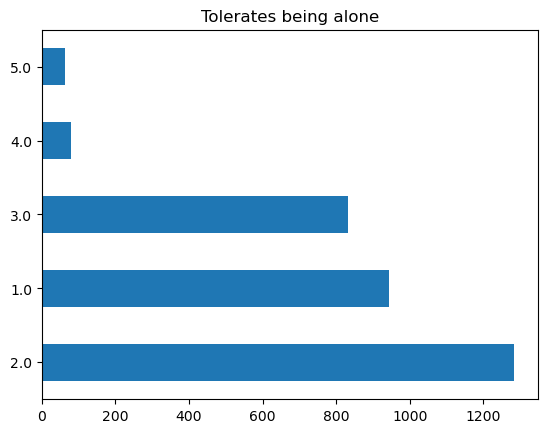

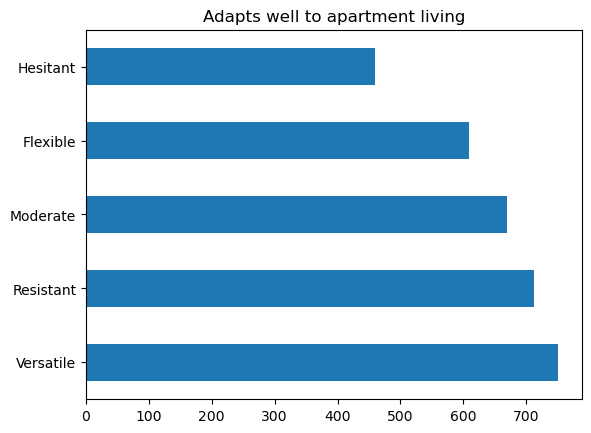

In [11]:
data["tolerates_being_alone"].value_counts().plot.barh().set_title("Tolerates being alone");
plt.show()

data["adapts_well_to_apartment_living"].value_counts().plot.barh().set_title("Adapts well to apartment living");
plt.show()


Visualize as pie

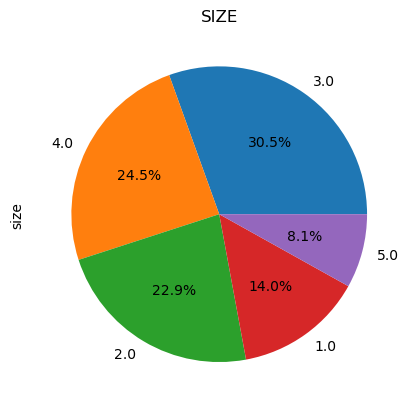

In [12]:
data["size"].value_counts().plot.pie(autopct="%1.1f%%")
plt.title('SIZE')
plt.show()


Comparing values with each other

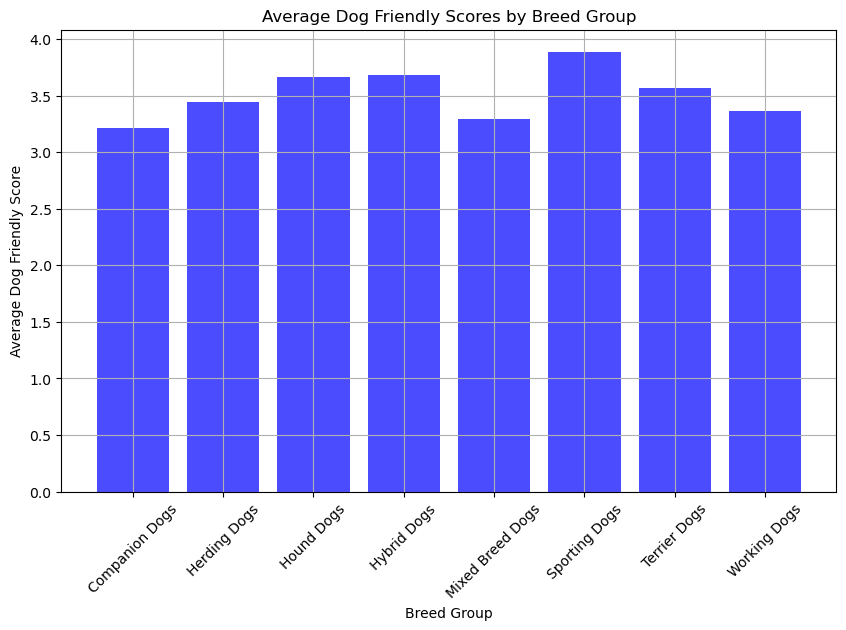

In [13]:
grouped_data = data_df.groupby('breed_group')['dog_friendly'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.bar(grouped_data['breed_group'], grouped_data['dog_friendly'], color='blue', alpha=0.7)
plt.title('Average Dog Friendly Scores by Breed Group')
plt.xlabel('Breed Group')
plt.ylabel('Average Dog Friendly Score')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Histogram

Text(0.5, 1.0, 'Distribution of Trainability')

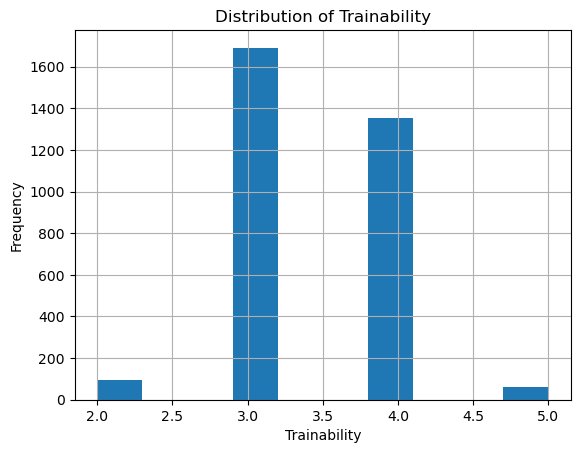

In [14]:
data['trainability'].hist()
plt.xlabel('Trainability')
plt.ylabel('Frequency')
plt.title('Distribution of Trainability')

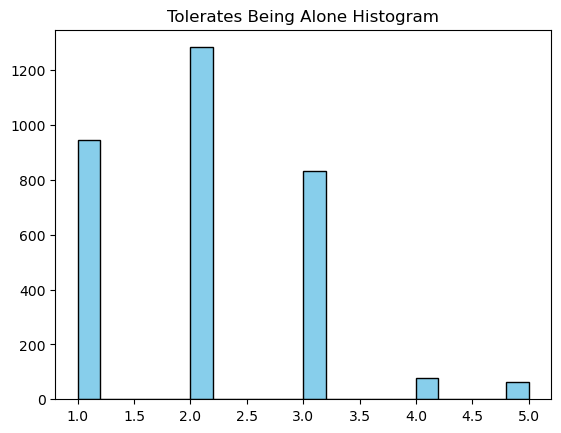

In [15]:
plt.hist(data['tolerates_being_alone'], bins=20, color='skyblue', edgecolor='black')
plt.title('Tolerates Being Alone Histogram')
plt.show()

# Correlation Matrix

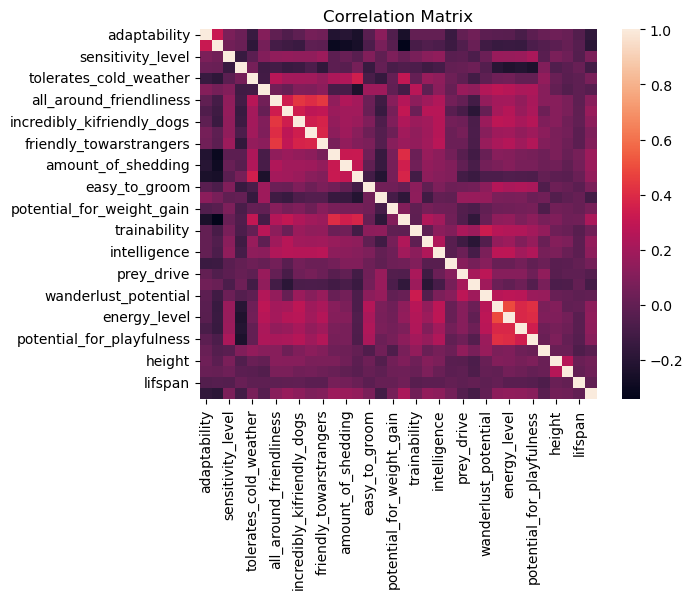

In [19]:
sns.heatmap(data.corr(), annot=False)
plt.title('Correlation Matrix')
plt.show()

Preprocessing for Model Training

In [17]:
height_mapping = {name: idx for idx, name in enumerate(data['height'].unique())}
weight_mapping = {name: idx for idx, name in enumerate(data['weight'].unique())}
lifspan_mapping = {name: idx for idx, name in enumerate(data['lifspan'].unique())}

data['breed_group'] = data['breed_group'].map({'Mixed Breed Dogs':0, 'Companion Dogs':1, 'Working Dogs':2, 'Terrier Dogs':3, 
                                               'Sporting Dogs':4, 'Hound Dogs':5, 'Hybrid Dogs':6,'Herding Dogs':7})
data['height'] = data['height'].map(height_mapping)
data['weight'] = data['weight'].map(weight_mapping)
data['lifspan'] = data['lifspan'].map(lifspan_mapping)
data['adapts_well_to_apartment_living'] = data['adapts_well_to_apartment_living'].map({'Flexible':0,'Moderate':1, 'Versatile':2,
                                                                                       'Resistant':3, 'Hesitant':4})

In [18]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

X = data.drop(['adapts_well_to_apartment_living'], axis=1)
y = data['adapts_well_to_apartment_living']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [23]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier()
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(X_train, y_train)
best_params_rf = grid_search_rf.best_params_
y_pred_rf = grid_search_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f'Accuracy: {accuracy_rf:.2f}')

Accuracy: 0.45


In [21]:
from sklearn.tree import DecisionTreeClassifier


dt = DecisionTreeClassifier()
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='accuracy')
grid_search_dt.fit(X_train, y_train)
best_params_dt = grid_search_dt.best_params_
y_pred_dt = grid_search_dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f'Accuracy: {accuracy_dt:.2f}')

Accuracy: 0.48


In [29]:
from sklearn.naive_bayes import GaussianNB
import numpy as np


gnb = GaussianNB()
param_grid_gnb = {
    'var_smoothing': np.logspace(-9, 0, 10)
}
grid_search_gnb = GridSearchCV(gnb, param_grid_gnb, cv=5, scoring='accuracy')
grid_search_gnb.fit(X_train, y_train)
best_params_gnb = grid_search_gnb.best_params_
y_pred_gnb = grid_search_gnb.predict(X_test)
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
print(f'Accuracy: {accuracy_gnb:.2f}')

Accuracy: 0.44


In [19]:
from sklearn.neighbors import KNeighborsClassifier


knn = KNeighborsClassifier()
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_search_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy')
grid_search_knn.fit(X_train, y_train)
best_params_knn = grid_search_knn.best_params_
y_pred_knn = grid_search_knn.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f'Accuracy: {accuracy_knn:.2f}')

Accuracy: 0.39


In [19]:
from sklearn.svm import SVC


svm = SVC()
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['linear', 'rbf', 'poly']
}
grid_search_svm = GridSearchCV(svm, param_grid_svm, cv=5, scoring='accuracy')
grid_search_svm.fit(X_train, y_train)
best_params_svm = grid_search_svm.best_params_
y_pred_svm = grid_search_svm.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f'Accuracy: {accuracy_svm:.2f}')

Accuracy: 0.43


In [28]:
best_params_svm

{'C': 1, 'gamma': 1, 'kernel': 'linear'}

In [29]:
accuracy_svm 

0.4328125

In [25]:
best_params_knn

{'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}

In [26]:
accuracy_knn

0.390625

In [27]:
best_params_rf

{'max_depth': 30,
 'max_features': 'auto',
 'min_samples_leaf': 4,
 'min_samples_split': 10,
 'n_estimators': 200}

In [30]:
best_params_gnb

{'var_smoothing': 1e-09}

In [31]:
best_params_dt

{'criterion': 'gini',
 'max_depth': 10,
 'min_samples_leaf': 4,
 'min_samples_split': 10,
 'splitter': 'random'}

In [32]:
accuracy_rf

0.453125

In [33]:
accuracy_gnb

0.4390625

In [34]:
accuracy_dt

0.375

In [35]:
results = {
    'Model': ['kNN', 'SVM', 'Random Forest', 'GaussianNB', 'Decision Tree'],
    'Best Parameters': [best_params_knn, best_params_svm, best_params_rf, best_params_gnb, best_params_dt],
    'Accuracy': [accuracy_knn, accuracy_svm, accuracy_rf, accuracy_gnb, accuracy_dt]
}

results_df = pd.DataFrame(results)

pd.set_option('display.max_colwidth', None)
results_df

,Model,Best Parameters,Accuracy
0,kNN,"{'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}",0.390625
1,SVM,"{'C': 1, 'gamma': 1, 'kernel': 'linear'}",0.432812
2,Random Forest,"{'max_depth': 30, 'max_features': 'auto', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}",0.453125
3,GaussianNB,{'var_smoothing': 1e-09},0.439063
4,Decision Tree,"{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'splitter': 'random'}",0.375000
